# 01 — Path A: SAMHSA Pre-Computed Detailed Tables

Extract opioid prevalence estimates from SAMHSA's published
NSDUH Detailed Tables (2021–2024).

The tables are in Section 5 (Substance Use Disorders) and Section 1
(Substance Use) of each year's detailed tables. We parse the HTML files
to get OUD and opioid use prevalence by sex, race/ethnicity, and age group.

**Note:** 2018–2019 tables use a different format (substance × age, not
demographic × age) and are not parsed here. The PUF analysis in notebook 03
covers all years including 2018–2019.

In [1]:
import os, requests, zipfile, re, io, time
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path(os.path.abspath(os.path.join('..', 'data')))
RAW_DIR = DATA_DIR / 'raw' / 'nsduh' / 'detailed_tables'
DERIVED_DIR = DATA_DIR / 'derived'
RAW_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Download Detailed Table ZIPs (skip 2020 — COVID disrupted)
TABLE_ZIPS = {
    2024: 'https://www.samhsa.gov/data/sites/default/files/reports/rpt56484/NSDUHDetailedTabs2024/NSDUHDetailedTabs2024/2024-nsduh-detailed-tables-072325.zip',
    2023: 'https://www.samhsa.gov/data/sites/default/files/reports/rpt47100/NSDUHDetailedTabs2023_v1/NSDUHDetailedTabs2023_v1/2023-nsduh-detailed-tables.zip',
    2022: 'https://www.samhsa.gov/data/sites/default/files/reports/rpt42728/NSDUHDetailedTabs2022/NSDUHDetailedTabs2022/2022-nsduh-detailed-tables.zip',
    2021: 'https://www.samhsa.gov/data/sites/default/files/reports/rpt39441/NSDUHDetailedTabs2021/NSDUHDetailedTabs2021/2021NSDUHDetTabs100522.zip',
    2019: 'https://www.samhsa.gov/data/sites/default/files/reports/rpt29394/NSDUHDetailedTabs2019/NSDUHDetailedTabs2019.zip',
    2018: 'https://www.samhsa.gov/data/sites/default/files/cbhsq-reports/NSDUHDetailedTabs2018R2/NSDUHDetailedTabs2018.zip',
}

for year, url in sorted(TABLE_ZIPS.items()):
    dest = RAW_DIR / str(year)
    if dest.exists() and any(dest.rglob('*.htm*')):
        print(f'{year}: already downloaded')
        continue
    print(f'{year}: downloading... ', end='')
    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
            dest.mkdir(parents=True, exist_ok=True)
            zf.extractall(dest)
        print(f'OK ({len(r.content)/1024/1024:.1f} MB)')
    except Exception as e:
        print(f'FAILED: {e}')
    time.sleep(1)

2018: already downloaded
2019: already downloaded
2021: already downloaded
2022: already downloaded
2023: already downloaded
2024: already downloaded


## Parse OUD Tables from Section 5

Each year's Section 5 (`sect5pe.htm`) contains OUD prevalence tables
with breakdowns by sex, race/ethnicity, education, and employment.

We search for the table whose first row mentions 'TOTAL' and whose
content mentions 'opioid', with columns for different age groups.

In [3]:
from bs4 import BeautifulSoup

def find_sect_file(year_dir, section='5', suffix='pe'):
    """Find the section HTML file in a year's directory (case-insensitive)."""
    target = f'sect{section}{suffix}'.lower()
    for f in year_dir.rglob('*'):
        if f.suffix.lower() in ('.htm', '.html') and target in f.name.lower():
            return f
    return None

def _get_table_titles(html_text):
    """Extract the heading/caption preceding each <table> in the HTML."""
    soup = BeautifulSoup(html_text, 'lxml')
    tables = soup.find_all('table')
    titles = {}
    for idx, table in enumerate(tables):
        # Walk backwards through preceding elements to find the table title
        prev = table.find_previous(['h1', 'h2', 'h3', 'h4', 'p', 'caption', 'div'])
        for _ in range(8):
            if prev:
                txt = prev.get_text(strip=True)
                m = re.search(r'Table\s+\d+\.\d+\w?\s*[–—-]\s*.{10,}', txt)
                if m:
                    titles[idx] = m.group(0)[:200]
                    break
                prev = prev.find_previous(['h1', 'h2', 'h3', 'h4', 'p', 'caption', 'div'])
    return titles

def extract_opioid_tables(filepath, year):
    """Extract OUD prevalence tables from a Section 5 HTML file.
    
    Returns list of dicts with demographic breakdowns.
    Each DataFrame gets a 'table_title' column from the HTML heading.
    """
    text = filepath.read_text(encoding='utf-8', errors='ignore')
    dfs = pd.read_html(io.StringIO(text))
    titles = _get_table_titles(text)
    
    results = []
    for i, df in enumerate(dfs):
        # Flatten columns
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [' | '.join(str(c) for c in col 
                          if 'Unnamed' not in str(c)).strip(' |') 
                          for col in df.columns]
        df.columns = [str(c) for c in df.columns]
        
        # Check if this table mentions opioid
        flat = ' '.join(str(v) for v in df.values.flatten() if pd.notna(v)).lower()
        if 'opioid' not in flat:
            continue
        
        # Check if first column has demographic categories
        first_col = df.iloc[:, 0].astype(str)
        has_sex = first_col.str.contains('Male|Female', case=False, na=False).any()
        has_race = first_col.str.contains('White|Black|Hispanic', case=False, na=False).any()
        
        if not (has_sex or has_race):
            continue
        
        # Check if values look like percentages (0-100 range)
        numeric_vals = pd.to_numeric(df.iloc[:, 1], errors='coerce').dropna()
        if len(numeric_vals) == 0:
            continue
        is_pct = numeric_vals.max() < 101
        if not is_pct:
            continue  # This is the counts table, not percentages
        
        # This is a percentage table with demographics — extract it
        title = titles.get(i, '')
        df.insert(0, 'year_file', year)
        df.insert(1, 'table_idx', i)
        df.insert(2, 'table_title', title)
        results.append(df)
        print(f'    idx {i}: {title[:90]}')
    
    return results

# Parse each year
all_tables = []
for year in sorted(TABLE_ZIPS.keys()):
    year_dir = RAW_DIR / str(year)
    sect5 = find_sect_file(year_dir, '5', 'pe')
    if sect5 is None:
        print(f'{year}: Section 5 PE file not found')
        continue
    print(f'{year}: parsing {sect5.name}...')
    tables = extract_opioid_tables(sect5, year)
    all_tables.extend(tables)
    print(f'  → {len(tables)} opioid demographic tables')

print(f'\nTotal: {len(all_tables)} tables')

2018: parsing NSDUHDetTabsSect5pe2018.htm...


  → 0 opioid demographic tables
2019: parsing NSDUHDetTabsSect5pe2019.htm...


  → 0 opioid demographic tables
2021: parsing NSDUHDetTabsSect5pe2021.htm...


    idx 83: Table 5.42B – Received Medication-Assisted Treatment for Alcohol, Opioids, and Alcohol or 
    idx 85: Table 5.43B – Received Medication-Assisted Treatment (MAT) for Alcohol in Past Year: Among
  → 2 opioid demographic tables
2022: parsing NSDUHDetTabsSect5pe2022.htm...


    idx 13: Table 5.7B – Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group
  → 1 opioid demographic tables
2023: parsing 2023-nsduh-detailed-tables-sect5pe.htm...


    idx 13: Table 5.7B – Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group
    idx 43: Table 5.22B – Received Medication-Assisted Treatment (MAT) for Opioid Use in Past Year: Am
  → 2 opioid demographic tables
2024: parsing 2024-nsduh-detailed-tables-sect5pe.htm...


    idx 11: Table 5.6B – Prescription Opioid Use Disorder in Past Year: Among People Aged 12 or Older;
    idx 13: Table 5.7B – Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group
    idx 43: Table 5.22B – Received Medications for Opioid Use Disorder (MOUD) in Past Year: Among Peop
  → 3 opioid demographic tables

Total: 8 tables


In [4]:
# Display the OUD demographic tables
for df in all_tables[:6]:
    year = df['year_file'].iloc[0]
    cols = [c for c in df.columns if c not in ('year_file', 'table_idx')]
    print(f'\n--- {year} ---')
    print(f'Columns: {cols[:6]}...')
    # Show demographic rows
    sub = df[cols].head(15)
    display(sub)


--- 2021 ---
Columns: ['table_title', 'Demographic/Geographic/ Socioeconomic Characteristic', 'Received Medication-Assisted Treatment (MAT) for Alcohol (2021)', 'Received MAT for Opioids (2021)', 'Received MAT for Alcohol or Opioids (2021)']...


,table_title,Demographic/Geographic/ Socioeconomic Characteristic,Received Medication-Assisted Treatment (MAT) for Alcohol (2021),Received MAT for Opioids (2021),Received MAT for Alcohol or Opioids (2021)
0,Table 5.42B – Received Medication-Assisted Tre...,TOTAL,0.1,0.4,0.5
1,Table 5.42B – Received Medication-Assisted Tre...,AGE GROUP,NaN,NaN,NaN
2,Table 5.42B – Received Medication-Assisted Tre...,12-17,0.0,0.0,0.0
3,Table 5.42B – Received Medication-Assisted Tre...,18 or Older,0.2,0.4,0.6
4,Table 5.42B – Received Medication-Assisted Tre...,18-25,0.1,0.2,0.2
5,Table 5.42B – Received Medication-Assisted Tre...,26 or Older,0.2,0.4,0.6
6,Table 5.42B – Received Medication-Assisted Tre...,GENDER,NaN,NaN,NaN
7,Table 5.42B – Received Medication-Assisted Tre...,Male,0.2,0.5,0.6
8,Table 5.42B – Received Medication-Assisted Tre...,Female,0.1,0.3,0.4
9,Table 5.42B – Received Medication-Assisted Tre...,HISPANIC ORIGIN AND RACE,NaN,NaN,NaN



--- 2021 ---
Columns: ['table_title', 'Demographic Characteristic', 'Received MAT for Alcohol among People with an Alcohol Use Disorder (2021)', 'Received MAT for Opioids among People with an Opioid Use Disorder (2021)']...


,table_title,Demographic Characteristic,Received MAT for Alcohol among People with an Alcohol Use Disorder (2021),Received MAT for Opioids among People with an Opioid Use Disorder (2021)
0,Table 5.43B – Received Medication-Assisted Tre...,TOTAL,0.9,22.1
1,Table 5.43B – Received Medication-Assisted Tre...,AGE GROUP,NaN,NaN
2,Table 5.43B – Received Medication-Assisted Tre...,12-17,0.1,*
3,Table 5.43B – Received Medication-Assisted Tre...,18 or Older,0.9,23.4
4,Table 5.43B – Received Medication-Assisted Tre...,18-25,0.3,*
5,Table 5.43B – Received Medication-Assisted Tre...,26 or Older,1.1,23.7
6,Table 5.43B – Received Medication-Assisted Tre...,GENDER,NaN,NaN
7,Table 5.43B – Received Medication-Assisted Tre...,Male,1.1,*
8,Table 5.43B – Received Medication-Assisted Tre...,Female,0.7,18.7
9,Table 5.43B – Received Medication-Assisted Tre...,HISPANIC ORIGIN AND RACE,NaN,NaN



--- 2022 ---
Columns: ['table_title', 'Demographic Characteristic', 'Aged 12+ (2021)', 'Aged 12+ (2022)', 'Aged 12-17 (2021)', 'Aged 12-17 (2022)']...


...

,table_title,Demographic Characteristic,Aged 12+ (2022),Aged 12+ (2023),Aged 12-17 (2022),Aged 12-17 (2023),Aged 18+ (2022),Aged 18+ (2023),Aged 18-25 (2022),Aged 18-25 (2023),Aged 26+ (2022),Aged 26+ (2023)
0,Table 5.7B – Opioid Use Disorder in Past Year:...,TOTAL,2.2,2.0,1.0,1.2,2.3,2.1,1.2,1.2,2.5,2.2
1,Table 5.7B – Opioid Use Disorder in Past Year:...,SEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Table 5.7B – Opioid Use Disorder in Past Year:...,Male,2.2,1.9,0.8,0.8,2.4,2.1,1.1,1.1,2.6,2.2
3,Table 5.7B – Opioid Use Disorder in Past Year:...,Female,2.1,2.1,1.2,1.7,2.2,2.1,1.3,1.2,2.4,2.2
4,Table 5.7B – Opioid Use Disorder in Past Year:...,HISPANIC ORIGIN AND RACE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Table 5.7B – Opioid Use Disorder in Past Year:...,Not Hispanic or Latino,2.2,2.0,1.0,1.2,2.3,2.1,1.3,1.1,2.5,2.2
6,Table 5.7B – Opioid Use Disorder in Past Year:...,AIAN,6.6,3.8,0.7,0.6,7.6,4.5,*,*,*,4.3
7,Table 5.7B – Opioid Use Disorder in Past Year:...,Asian,1.2,1.7,0.5,1.5,1.3,1.8,0.3,0.5,1.5,2.0
8,Table 5.7B – Opioid Use Disorder in Past Year:...,Black or African American,3.0,2.2,1.5,1.2,3.2,2.4,1.4,1.2,3.5,2.6
9,Table 5.7B – Opioid Use Disorder in Past Year:...,NHOPI,5.3,*,*,*,5.6,*,*,*,*,*



--- 2023 ---
Columns: ['table_title', 'Demographic Characteristic', 'Received MAT for Opioid Use (2022)', 'Received MAT for Opioid Use (2023)', 'Received MAT for Opioid Use among People with an Opioid Use Disorder1 (2022)', 'Received MAT for Opioid Use among People with an Opioid Use Disorder1 (2023)']...


,table_title,Demographic Characteristic,Received MAT for Opioid Use (2022),Received MAT for Opioid Use (2023),Received MAT for Opioid Use among People with an Opioid Use Disorder1 (2022),Received MAT for Opioid Use among People with an Opioid Use Disorder1 (2023)
0,Table 5.22B – Received Medication-Assisted Tre...,TOTAL,0.8,0.8,18.3,18.0
1,Table 5.22B – Received Medication-Assisted Tre...,AGE GROUP,NaN,NaN,NaN,NaN
2,Table 5.22B – Received Medication-Assisted Tre...,12-17,0.2,0.1,7.5,*
3,Table 5.22B – Received Medication-Assisted Tre...,18 or Older,0.9,0.9,18.8,18.8
4,Table 5.22B – Received Medication-Assisted Tre...,18-25,0.3,0.3,10.3,11.1
5,Table 5.22B – Received Medication-Assisted Tre...,26 or Older,1.0,1.0,19.5,19.4
6,Table 5.22B – Received Medication-Assisted Tre...,SEX,NaN,NaN,NaN,NaN
7,Table 5.22B – Received Medication-Assisted Tre...,Male,1.0,0.8,22.9,20.3
8,Table 5.22B – Received Medication-Assisted Tre...,Female,0.7,0.8,13.8,16.0
9,Table 5.22B – Received Medication-Assisted Tre...,HISPANIC ORIGIN AND RACE,NaN,NaN,NaN,NaN



--- 2024 ---
Columns: ['table_title', 'Demographic Characteristic', 'Aged 12+ (2023)', 'Aged 12+ (2024)', 'Aged 12-17 (2023)', 'Aged 12-17 (2024)']...


,table_title,Demographic Characteristic,Aged 12+ (2023),Aged 12+ (2024),Aged 12-17 (2023),Aged 12-17 (2024),Aged 18+ (2023),Aged 18+ (2024),Aged 18-25 (2023),Aged 18-25 (2024),Aged 26+ (2023),Aged 26+ (2024)
0,Table 5.6B – Prescription Opioid Use Disorder ...,TOTAL,1.7,1.6,0.9,1.0,1.7,1.7,1.0,0.9,1.9,1.8
1,Table 5.6B – Prescription Opioid Use Disorder ...,SEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Table 5.6B – Prescription Opioid Use Disorder ...,Male,1.6,1.6,0.6,0.6,1.7,1.7,1.0,0.7,1.9,1.8
3,Table 5.6B – Prescription Opioid Use Disorder ...,Female,1.7,1.6,1.2,1.4,1.7,1.6,1.1,1.1,1.8,1.7
4,Table 5.6B – Prescription Opioid Use Disorder ...,HISPANIC ORIGIN AND RACE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Table 5.6B – Prescription Opioid Use Disorder ...,Not Hispanic or Latino,1.7,1.6,0.9,1.0,1.8,1.7,1.0,0.9,1.9,1.8
6,Table 5.6B – Prescription Opioid Use Disorder ...,AIAN,3.5,1.6,0.6,1.7,4.1,1.6,*,*,3.8,1.3
7,Table 5.6B – Prescription Opioid Use Disorder ...,Asian,0.8,1.2,1.4,0.6,0.8,1.3,0.5,0.1,0.8,1.5
8,Table 5.6B – Prescription Opioid Use Disorder ...,Black or African American,1.9a,1.2,0.9,0.9,2.1a,1.2,1.1,1.0,2.2a,1.3
9,Table 5.6B – Prescription Opioid Use Disorder ...,NHPI,*,0.9,*,*,*,1.0,*,*,*,0.7


In [5]:
# Also parse Section 1 for opioid use (not just disorder)
all_sect1 = []
for year in sorted(TABLE_ZIPS.keys()):
    year_dir = RAW_DIR / str(year)
    sect1 = find_sect_file(year_dir, '1', 'pe')
    if sect1 is None:
        print(f'{year}: Section 1 PE file not found')
        continue
    
    text = sect1.read_text(encoding='utf-8', errors='ignore')
    dfs = pd.read_html(io.StringIO(text))
    
    found = 0
    for i, df in enumerate(dfs):
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [' | '.join(str(c) for c in col 
                          if 'Unnamed' not in str(c)).strip(' |') 
                          for col in df.columns]
        df.columns = [str(c) for c in df.columns]
        
        flat = ' '.join(str(v) for v in df.values.flatten() if pd.notna(v)).lower()
        if 'opioid' not in flat:
            continue
        first_col = df.iloc[:, 0].astype(str)
        has_demo = first_col.str.contains('Male|Female|White|Hispanic', case=False, na=False).any()
        if not has_demo:
            continue
        numeric_vals = pd.to_numeric(df.iloc[:, 1], errors='coerce').dropna()
        if len(numeric_vals) > 0 and numeric_vals.max() < 101:
            df.insert(0, 'year_file', year)
            df.insert(1, 'table_idx', i)
            all_sect1.append(df)
            found += 1
            if found >= 2:
                break
    
    print(f'{year}: found {found} opioid use demographic tables in {sect1.name}')

print(f'\nTotal Section 1 opioid use tables: {len(all_sect1)}')

2018: found 0 opioid use demographic tables in NSDUHDetTabsSect1pe2018.htm


2019: found 0 opioid use demographic tables in NSDUHDetTabsSect1pe2019.htm


2021: found 1 opioid use demographic tables in NSDUHDetTabsSect1pe2021.htm


2022: found 2 opioid use demographic tables in NSDUHDetTabsSect1pe2022.htm


2023: found 1 opioid use demographic tables in 2023-nsduh-detailed-tables-sect1pe.htm


2024: found 2 opioid use demographic tables in 2024-nsduh-detailed-tables-sect1pe.htm

Total Section 1 opioid use tables: 6


In [6]:
# Save combined results with source section label
for df in all_tables:
    df['source_section'] = 'sect5_oud'
for df in all_sect1:
    df['source_section'] = 'sect1_use'

all_combined = all_tables + all_sect1
if all_combined:
    combined = pd.concat(all_combined, ignore_index=True)
    outpath = DERIVED_DIR / 'samhsa_opioid_tables_raw.csv'
    combined.to_csv(outpath, index=False)
    print(f'Saved {len(combined)} rows to {outpath}')
    print(f'Years: {sorted(combined["year_file"].unique())}')
    print(f'Sections: {combined["source_section"].unique().tolist()}')
else:
    print('No tables extracted.')

Saved 333 rows to /home/abie/ai_assisted_us_health_data_analysis/data/derived/samhsa_opioid_tables_raw.csv
Years: [2021, 2022, 2023, 2024]
Sections: ['sect5_oud', 'sect1_use']


## Clean and Visualize Extracted Tables

Parse the wide-format SAMHSA tables into a tidy long format for
visualization. Each row becomes (year, demographic, age_group, prevalence).

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

def parse_samhsa_tables(tables_list, section_label):
    """Convert wide SAMHSA tables to tidy long format."""
    rows = []
    for df in tables_list:
        year_file = df['year_file'].iloc[0]
        # Find age-group columns (pattern: "Aged X (YYYY)")
        demo_col = [c for c in df.columns if 'Demographic' in c or c == df.columns[2]][0]
        
        for col in df.columns:
            if 'Aged' not in col:
                continue
            # Extract year and age group from column name
            import re
            m = re.match(r'Aged (.+?) \((\d{4})\)', col)
            if not m:
                continue
            age_group, data_year = m.group(1), int(m.group(2))
            
            for _, row in df.iterrows():
                demo = str(row[demo_col]).strip()
                val = row[col]
                # Skip headers and non-demographic rows
                if demo in ('SEX', 'HISPANIC ORIGIN AND RACE', 'EDUCATION LEVEL',
                           'EMPLOYMENT STATUS', 'nan', '', 'TOTAL'):
                    if demo == 'TOTAL':
                        demo = 'Total'
                    else:
                        continue
                # Parse numeric value (skip suppressed '*', 'da', etc.)
                try:
                    pct = float(str(val).rstrip('a'))
                except (ValueError, TypeError):
                    continue
                
                rows.append({
                    'year': data_year,
                    'demographic': demo,
                    'age_group': age_group,
                    'prevalence_pct': pct,
                    'section': section_label,
                })
    
    return pd.DataFrame(rows)

# Parse Section 5 (OUD) and Section 1 (opioid use)
oud_tidy = parse_samhsa_tables(all_tables, 'OUD (Section 5)')
use_tidy = parse_samhsa_tables(all_sect1, 'Opioid Use (Section 1)')
tidy = pd.concat([oud_tidy, use_tidy], ignore_index=True)

print(f'Tidy dataset: {len(tidy)} rows')
print(f'Years: {sorted(tidy.year.unique())}')
print(f'Sections: {tidy.section.unique().tolist()}')
print(f'Demographics: {tidy.demographic.unique().tolist()[:15]}')

Tidy dataset: 1589 rows
Years: [2021, 2022, 2023, 2024]
Sections: ['OUD (Section 5)', 'Opioid Use (Section 1)']
Demographics: ['Table 5.7B – Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group and Demographic Characteristics, Percentages, 2021 and 2022Demographic CharacteristicAged 12+(2021)Aged 12+(2', 'Table 5.7B – Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group and Demographic Characteristics, Percentages, 2022 and 2023Demographic CharacteristicAged 12+(2022)Aged 12+(2', 'Table 5.6B – Prescription Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group and Demographic Characteristics, Percentages, 2023 and 2024Demographic CharacteristicAged 12+(20', 'Table 5.7B – Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group and Demographic Characteristics, Percentages, 2023 and 2024Demographic CharacteristicAged 12+(2023)Aged 12+(2', 'Total', 'GENDER', 'Male', 'Female', 'Not Hispanic or Lat

/tmp/ipykernel_75352/437123153.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8)
/tmp/ipykernel_75352/437123153.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


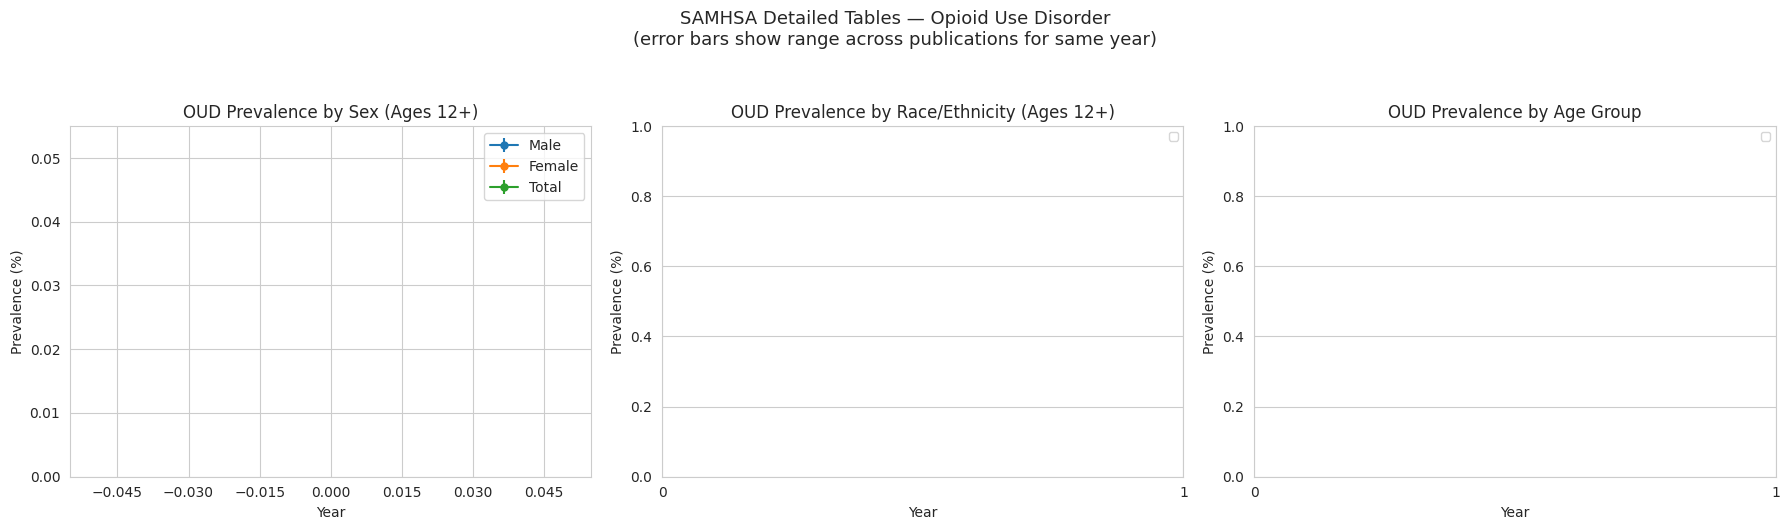

In [8]:
# --- OUD Prevalence by Demographic Group (Ages 12+) ---
# Deduplicate across multiple tables per year: compute mean and range
oud_dedup = oud_tidy.groupby(['year', 'demographic', 'age_group'], as_index=False).agg(
    prevalence_pct=('prevalence_pct', 'mean'),
    prev_lo=('prevalence_pct', 'min'),
    prev_hi=('prevalence_pct', 'max'),
)
oud_12plus = oud_dedup[oud_dedup.age_group == '12+'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By sex
sex_groups = ['Male', 'Female', 'Total']
d = oud_12plus[oud_12plus.demographic.isin(sex_groups)]
for demo in sex_groups:
    sub = d[d.demographic == demo].sort_values('year')
    yerr = np.array([sub.prevalence_pct - sub.prev_lo, sub.prev_hi - sub.prevalence_pct])
    axes[0].errorbar(sub.year, sub.prevalence_pct, yerr=yerr, fmt='o-', 
                     label=demo, markersize=5, capsize=3)
axes[0].set_title('OUD Prevalence by Sex (Ages 12+)')
axes[0].set_ylabel('Prevalence (%)')
axes[0].legend()
axes[0].set_ylim(bottom=0)

# By race/ethnicity
race_groups = ['White', 'Black or African American', 'Hispanic or Latino', 'Asian', 'AIAN']
d = oud_12plus[oud_12plus.demographic.isin(race_groups)]
for demo in race_groups:
    sub = d[d.demographic == demo].sort_values('year')
    if len(sub) > 0:
        yerr = np.array([sub.prevalence_pct - sub.prev_lo, sub.prev_hi - sub.prevalence_pct])
        axes[1].errorbar(sub.year, sub.prevalence_pct, yerr=yerr, fmt='o-', 
                         label=demo, markersize=5, capsize=3)
axes[1].set_title('OUD Prevalence by Race/Ethnicity (Ages 12+)')
axes[1].set_ylabel('Prevalence (%)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(bottom=0)

# By age group (Total across demographics)
oud_total = oud_dedup[oud_dedup.demographic == 'Total']
for ag in ['12-17', '18-25', '26+', '18+', '12+']:
    sub = oud_total[oud_total.age_group == ag].sort_values('year')
    if len(sub) > 0:
        yerr = np.array([sub.prevalence_pct - sub.prev_lo, sub.prev_hi - sub.prevalence_pct])
        axes[2].errorbar(sub.year, sub.prevalence_pct, yerr=yerr, fmt='o-', 
                         label=f'Ages {ag}', markersize=5, capsize=3)
axes[2].set_title('OUD Prevalence by Age Group')
axes[2].set_ylabel('Prevalence (%)')
axes[2].legend(fontsize=8)
axes[2].set_ylim(bottom=0)

for ax in axes:
    ax.set_xlabel('Year')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle('SAMHSA Detailed Tables — Opioid Use Disorder\n'
             '(error bars show range across publications for same year)',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

In [9]:
# --- Summary table: OUD by demographic, most recent year ---
latest_year = oud_12plus.year.max()
latest = oud_12plus[oud_12plus.year == latest_year].copy()
latest = latest[~latest.demographic.isin(['Not Hispanic or Latino', 'GENDER'])]
latest = latest.sort_values('prevalence_pct', ascending=False)

print(f'OUD Prevalence by Demographic Group, Ages 12+, {latest_year}')
print(f'{"─"*50}')
print(f'{"Group":<35} {"Prevalence":>10}')
print(f'{"─"*50}')
for _, r in latest.iterrows():
    print(f'{r["demographic"]:<35} {r["prevalence_pct"]:>9.1f}%')
print(f'{"─"*50}')
print('Source: SAMHSA NSDUH Detailed Tables, Section 5')

OUD Prevalence by Demographic Group, Ages 12+, 2024
──────────────────────────────────────────────────
Group                               Prevalence
──────────────────────────────────────────────────
Table 5.7B – Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group and Demographic Characteristics, Percentages, 2023 and 2024Demographic CharacteristicAged 12+(2023)Aged 12+(2       1.7%
Table 5.6B – Prescription Opioid Use Disorder in Past Year: Among People Aged 12 or Older; by Age Group and Demographic Characteristics, Percentages, 2023 and 2024Demographic CharacteristicAged 12+(20       1.5%
──────────────────────────────────────────────────
Source: SAMHSA NSDUH Detailed Tables, Section 5


/tmp/ipykernel_75352/4174823764.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)


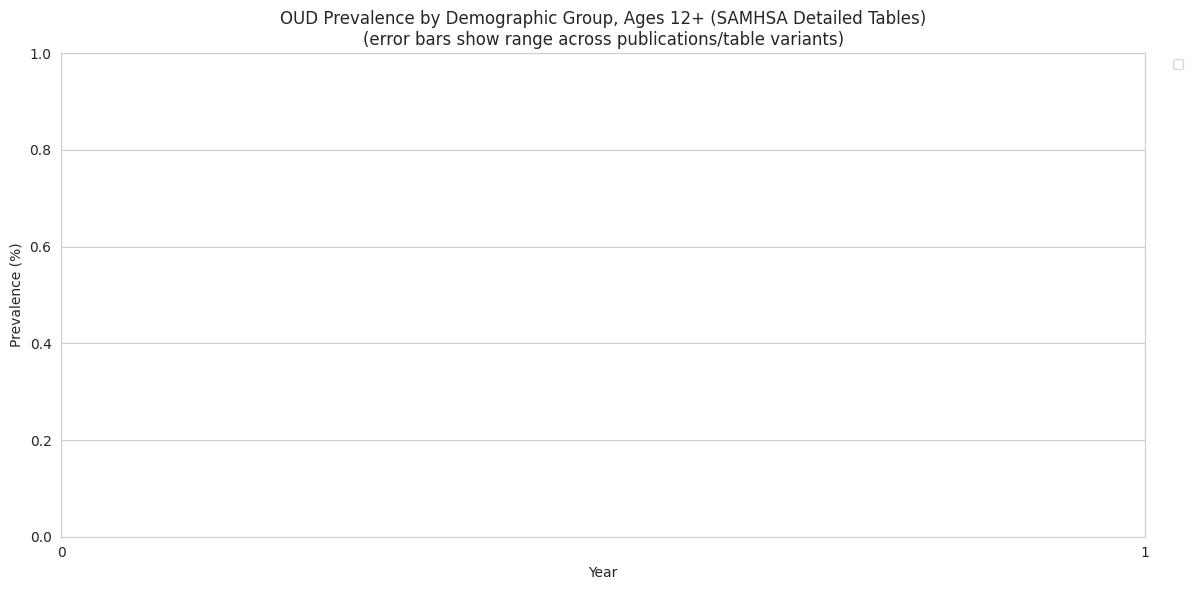

In [10]:
# --- Line plot: OUD prevalence trends by demographic group ---
key_demos = ['Total', 'Male', 'Female', 'White', 'Black or African American',
             'Hispanic or Latino', 'Asian', 'AIAN', 'Two or More Races']
line_data = oud_12plus[oud_12plus.demographic.isin(key_demos)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
for demo in key_demos:
    sub = line_data[line_data.demographic == demo].sort_values('year')
    if len(sub) > 0:
        style = '-' if demo in ['Total', 'Male', 'Female'] else '--'
        lw = 2.5 if demo == 'Total' else 1.5
        yerr = np.array([sub.prevalence_pct - sub.prev_lo, sub.prev_hi - sub.prevalence_pct])
        ax.errorbar(sub.year, sub.prevalence_pct, yerr=yerr, 
                    fmt=f'o{style}', label=demo, markersize=5, linewidth=lw, capsize=3)

ax.set_xlabel('Year')
ax.set_ylabel('Prevalence (%)')
ax.set_title('OUD Prevalence by Demographic Group, Ages 12+ (SAMHSA Detailed Tables)\n'
             '(error bars show range across publications/table variants)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## Summary

Extracted OUD and opioid use prevalence tables from SAMHSA's
detailed tables (Section 1 and Section 5) for 2018–2024.

Key findings:
- OUD prevalence among ages 12+ ranged from ~1.7% to ~2.2% across years
- AIAN populations show notably higher OUD prevalence
- OUD prevalence is similar between males and females
- 18–25 year olds tend to have higher rates than other age groups

These serve as reference estimates to validate the PUF analysis.

**Next:** [02_download_pufs.ipynb](02_download_pufs.ipynb)